In [1]:
import spacy

nlp = spacy.blank("en")

doc = nlp("Captain america ate 100$ of samosa. Then he said I can do this all day.")

for token in doc:
    print(token)

/usr/local/lib/python3.9/dist-packages/torch/cuda/__init__.py:497: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Captain
america
ate
100
$
of
samosa
.
Then
he
said
I
can
do
this
all
day
.


We get above error because we have a blank pipeline as shown below. Pipeline is something that starts with a Tokenizer component in a dotted rectange below. You can see there is nothing there hence the blank pipeline



In [2]:
nlp.pipe_names

[]

nlp.pipe_names is empty array indicating no components in the pipeline. Pipeline is something that starts with a tokenizer

More general diagram for nlp pipeline may look something like below
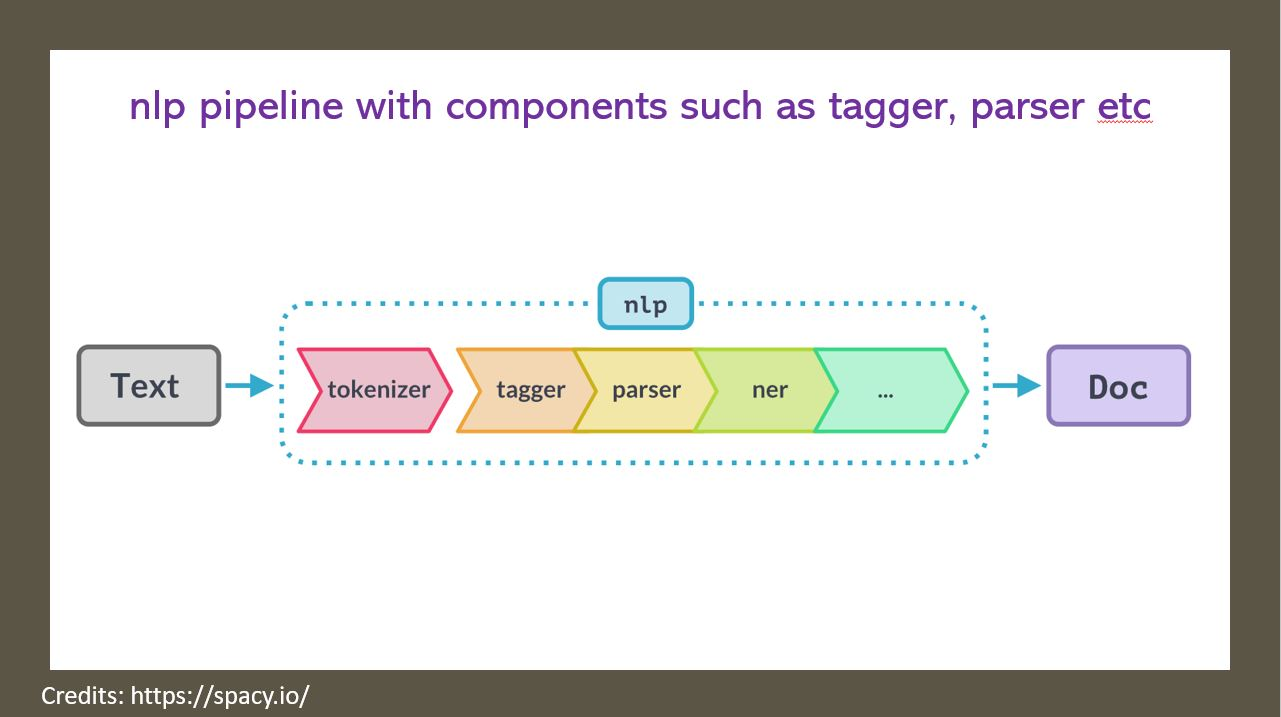



Download trained pipeline
To download trained pipeline use a command such as,

python -m spacy download en_core_web_sm

This downloads the small (sm) pipeline for english language

Further instructions on : https://spacy.io/usage/models#quickstart

In [3]:
nlp = spacy.load("en_core_web_sm")
nlp.pipe_names

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

In [4]:
nlp.pipeline

[('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x7fb45da20d00>),
 ('tagger', <spacy.pipeline.tagger.Tagger at 0x7fb45da20400>),
 ('parser', <spacy.pipeline.dep_parser.DependencyParser at 0x7fb45da216d0>),
 ('attribute_ruler',
  <spacy.pipeline.attributeruler.AttributeRuler at 0x7fb45d873dc0>),
 ('lemmatizer',
  <spacy.lang.en.lemmatizer.EnglishLemmatizer at 0x7fb45d95f1c0>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x7fb45da21660>)]

In [5]:
doc = nlp("Captain america ate 100$ of samosa. Then he said I can do this all day.")

for token in doc:
    print(token, " | ", spacy.explain(token.pos_), " | ", token.lemma_)

Captain  |  proper noun  |  Captain
america  |  proper noun  |  america
ate  |  verb  |  eat
100  |  numeral  |  100
$  |  numeral  |  $
of  |  adposition  |  of
samosa  |  proper noun  |  samosa
.  |  punctuation  |  .
Then  |  adverb  |  then
he  |  pronoun  |  he
said  |  verb  |  say
I  |  pronoun  |  I
can  |  auxiliary  |  can
do  |  verb  |  do
this  |  pronoun  |  this
all  |  determiner  |  all
day  |  noun  |  day
.  |  punctuation  |  .


Run same code above with a blank pipeline and check what output you see?

Named Entity Recognition

In [6]:
doc = nlp("Tesla Inc is going to acquire twitter for $45 billion")
for ent in doc.ents:
    print(ent.text, ent.label_)

Tesla Inc ORG
$45 billion MONEY


In [7]:
from spacy import displacy

displacy.render(doc, style="ent")

'<div class="entities" style="line-height: 2.5; direction: ltr">\n<mark class="entity" style="background: #7aecec; padding: 0.45em 0.6em; margin: 0 0.25em; line-height: 1; border-radius: 0.35em;">\n    Tesla Inc\n    <span style="font-size: 0.8em; font-weight: bold; line-height: 1; border-radius: 0.35em; vertical-align: middle; margin-left: 0.5rem">ORG</span>\n</mark>\n is going to acquire twitter for \n<mark class="entity" style="background: #e4e7d2; padding: 0.45em 0.6em; margin: 0 0.25em; line-height: 1; border-radius: 0.35em;">\n    $45 billion\n    <span style="font-size: 0.8em; font-weight: bold; line-height: 1; border-radius: 0.35em; vertical-align: middle; margin-left: 0.5rem">MONEY</span>\n</mark>\n</div>'

**Tesla Inc ORG va racheter Twitter MISC pour $45 milliards de dollars**
Trained processing pipeline in French

In [11]:
!python -m spacy download fr_core_news_sm


/usr/local/lib/python3.9/dist-packages/torch/cuda/__init__.py:497: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
2023-03-29 05:31:25.447650: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2023-03-29 05:31:25.447780: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2023-03-29 05:31:25.447803: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Cannot dlopen some TensorRT libraries. If you would like to use Nvidia GPU with TensorRT, please make sure the missing libraries mentione

In [12]:
nlp = spacy.load("fr_core_news_sm")

In [13]:
doc = nlp("Tesla Inc va racheter Twitter pour $45 milliards de dollars")
for ent in doc.ents:
    print(ent.text, " | ", ent.label_, " | ", spacy.explain(ent.label_))

Tesla Inc  |  ORG  |  Companies, agencies, institutions, etc.
Twitter  |  MISC  |  Miscellaneous entities, e.g. events, nationalities, products or works of art


In [14]:
for token in doc:
    print(token, " | ", token.pos_, " | ", token.lemma_)


Tesla  |  PROPN  |  Tesla
Inc  |  PROPN  |  Inc
va  |  VERB  |  aller
racheter  |  VERB  |  racheter
Twitter  |  VERB  |  twitter
pour  |  ADP  |  pour
$  |  NOUN  |  dollar
45  |  NUM  |  45
milliards  |  NOUN  |  milliard
de  |  ADP  |  de
dollars  |  NOUN  |  dollar


## Adding a component to a blank pipeline

In [15]:
source_nlp = spacy.load("en_core_web_sm")

nlp = spacy.blank("en")
nlp.add_pipe("ner", source=source_nlp)
nlp.pipe_names

['ner']

In [16]:
doc = nlp("Tesla Inc is going to acquire twitter for $45 billion")
for ent in doc.ents:
    print(ent.text, ent.label_)

Tesla Inc ORG
$45 billion MONEY


In below image you can see sentecizer component in the pipeline

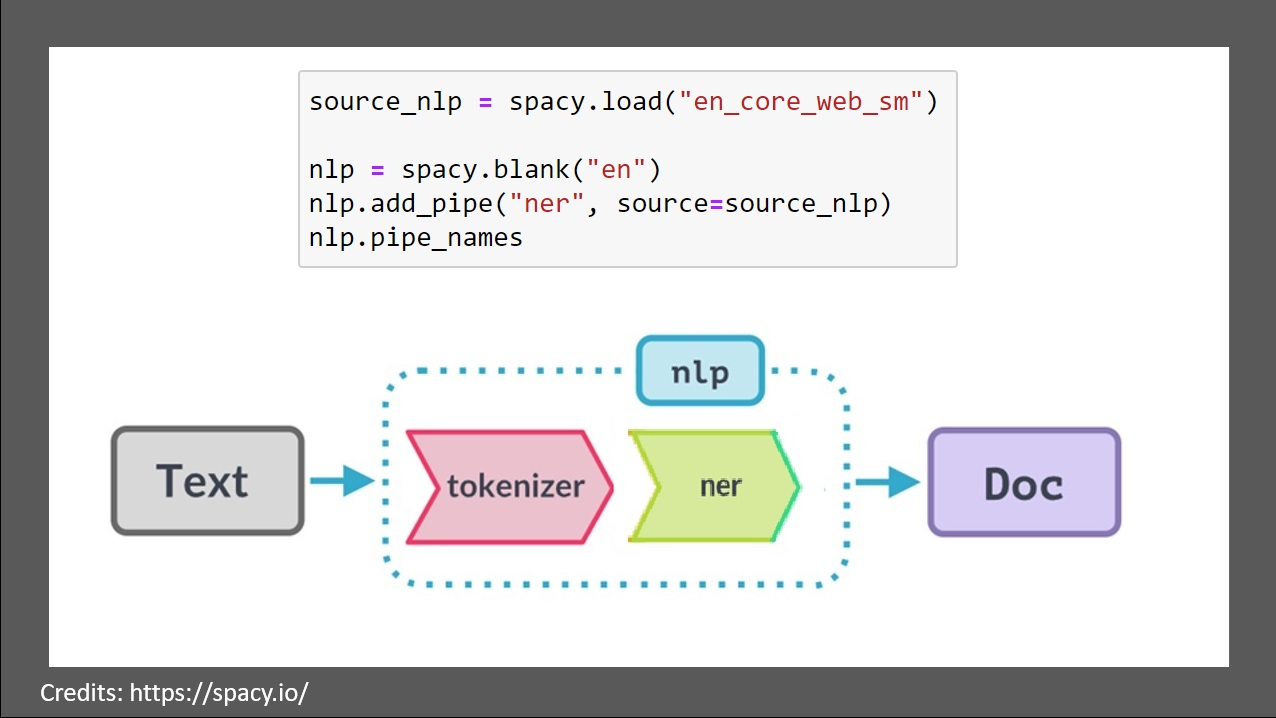